In [1]:
# Importing libraries Required for Forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
# Loading cleaned sales data
sales = pd.read_csv("../data/processed/sales_cleaned.csv")

# Converting Date column into datetime format
sales["Date"] = pd.to_datetime(sales["Date"])

# Checking the loaded data
print("Sales shape:", sales.shape)
sales.head()

Sales shape: (36550, 6)


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


In [3]:
# Creating weekly demand for each SKU
weekly_sales = (sales.groupby(["SKU",pd.Grouper(key="Date", freq="W-SUN")])
                ["Units_Sold"].sum().reset_index())

# Renaming columns for easier use
weekly_sales = weekly_sales.rename(columns={"Date": "Week","Units_Sold": "Weekly_Demand"})

# Checking weekly demand
weekly_sales.head()

,SKU,Week,Weekly_Demand
0,SKU001,2024-01-07,106
1,SKU001,2024-01-14,85
2,SKU001,2024-01-21,117
3,SKU001,2024-01-28,89
4,SKU001,2024-02-04,119


In [4]:
# Checking number of SKUs and weeks available
print("Number of SKUs:", weekly_sales["SKU"].nunique())
print("Number of weeks:", weekly_sales["Week"].nunique())
print("Weekly data shape:", weekly_sales.shape)

Number of SKUs: 50
Number of weeks: 105
Weekly data shape: (5250, 3)


In [5]:
# Creating a complete weekly timeline for every SKU
all_skus = weekly_sales["SKU"].unique()

all_weeks = pd.date_range(weekly_sales["Week"].min(),
    weekly_sales["Week"].max(),freq="W-SUN")

# Creating every possible SKU and week combination
complete_index = pd.MultiIndex.from_product([all_skus, all_weeks],names=["SKU", "Week"])

# Filling missing SKU-week Combinations with zero demand
weekly_sales = (weekly_sales.set_index(["SKU", "Week"]).reindex(complete_index, fill_value=0).reset_index())

print("Complete weekly data shape:", weekly_sales.shape)
print("Missing values:", weekly_sales.isnull().sum().sum())

Complete weekly data shape: (5250, 3)
Missing values: 0


In [7]:
# Sorting data by SKU and week
weekly_sales = weekly_sales.sort_values(["SKU", "Week"]).reset_index(drop=True)

weekly_sales.head()

,SKU,Week,Weekly_Demand
0,SKU001,2024-01-07,106
1,SKU001,2024-01-14,85
2,SKU001,2024-01-21,117
3,SKU001,2024-01-28,89
4,SKU001,2024-02-04,119


In [8]:
# Creating a seasonal naive forecast using demand from 52 weeks earlier
weekly_sales["Seasonal_Naive"] = (weekly_sales.groupby("SKU")["Weekly_Demand"].shift(52))

# Checking the seasonal naive values
weekly_sales[["SKU", "Week", "Weekly_Demand", "Seasonal_Naive"]].head(60)

,SKU,Week,Weekly_Demand,Seasonal_Naive
0,SKU001,2024-01-07,106,NaN
1,SKU001,2024-01-14,85,NaN
2,SKU001,2024-01-21,117,NaN
3,SKU001,2024-01-28,89,NaN
4,SKU001,2024-02-04,119,NaN
5,SKU001,2024-02-11,112,NaN
6,SKU001,2024-02-18,104,NaN
7,SKU001,2024-02-25,120,NaN
8,SKU001,2024-03-03,103,NaN
9,SKU001,2024-03-10,119,NaN


In [9]:
# Creating previous-week and historical demand features
for lag in [1, 2, 4, 8, 13, 26, 52]:
    weekly_sales[f"Lag_{lag}"] = (weekly_sales.groupby("SKU")["Weekly_Demand"].shift(lag))

In [10]:
# Creating rolling average demand features

weekly_sales["Rolling_Mean_4"] = (weekly_sales.groupby("SKU")["Weekly_Demand"]
                                  .transform(lambda x: x.shift(1).rolling(4).mean()))

weekly_sales["Rolling_Mean_8"] = (weekly_sales.groupby("SKU")["Weekly_Demand"]
                                  .transform(lambda x: x.shift(1).rolling(8).mean()))

weekly_sales["Rolling_Mean_13"] = (weekly_sales.groupby("SKU")["Weekly_Demand"]
                                   .transform(lambda x: x.shift(1).rolling(13).mean()))

In [11]:
# Creating calendar features from the week date
weekly_sales["Year"] = weekly_sales["Week"].dt.year
weekly_sales["Month"] = weekly_sales["Week"].dt.month
weekly_sales["Quarter"] = weekly_sales["Week"].dt.quarter

weekly_sales["Week_Number"] = (weekly_sales["Week"].dt.isocalendar().week.astype(int))

In [12]:
# Removing rows where forecasting features are not available
forecast_data = weekly_sales.dropna().copy()

print("Forecast data shape:", forecast_data.shape)
print("Missing values:", forecast_data.isnull().sum().sum())

Forecast data shape: (2650, 18)
Missing values: 0


In [13]:
# Creating a time-based train and test split
last_week = forecast_data["Week"].max()

test_start = last_week - pd.Timedelta(weeks=7)
train_data = forecast_data[forecast_data["Week"] < test_start].copy()
test_data = forecast_data[forecast_data["Week"] >= test_start].copy()

print("Train period:",train_data["Week"].min(),"to",train_data["Week"].max())
print("Test period:",test_data["Week"].min(),"to",test_data["Week"].max())

Train period: 2025-01-05 00:00:00 to 2025-11-09 00:00:00
Test period: 2025-11-16 00:00:00 to 2026-01-04 00:00:00


In [14]:
# Selecting features that will be used by the forecasting model
features = ["Lag_1","Lag_2","Lag_4","Lag_8","Lag_13","Lag_26","Lag_52",
            "Rolling_Mean_4","Rolling_Mean_8","Rolling_Mean_13","Year","Month","Quarter","Week_Number"]

# Defining the value that the model needs to predict
target = "Weekly_Demand"

In [15]:
# Creating the gradient boosting forecasting model
model = HistGradientBoostingRegressor(max_iter=300,learning_rate=0.05,
                                      max_leaf_nodes=31,l2_regularization=1.0,random_state=42)

# Training the model using historical demand
model.fit(train_data[features],train_data[target])
print("Forecasting model trained successfully")

Forecasting model trained successfully


In [16]:
# Generating predictions for the test period
test_data["Forecast"] = model.predict(test_data[features])

# Making sure forecasted demand cannot be negative
test_data["Forecast"] = test_data["Forecast"].clip(lower=0)
test_data[["SKU", "Week", "Weekly_Demand", "Forecast"]].head()

,SKU,Week,Weekly_Demand,Forecast
97,SKU001,2025-11-16,87,88.052858
98,SKU001,2025-11-23,84,93.603417
99,SKU001,2025-11-30,84,90.908105
100,SKU001,2025-12-07,88,91.172182
101,SKU001,2025-12-14,89,95.596350


In [17]:
# Creating a function to calculate WAPE
def calculate_wape(actual, predicted):
    denominator = np.abs(actual).sum()
    if denominator == 0:
        return np.nan
    return (np.abs(actual - predicted).sum()/ denominator* 100)

In [18]:
# Calculating WAPE for the forecasting model
model_wape = calculate_wape(test_data["Weekly_Demand"],test_data["Forecast"])

print("Model WAPE:", round(model_wape, 2), "%")

Model WAPE: 17.87 %


In [19]:
# Removing rows where the seasonal naive forecast is unavailable
baseline_data = test_data.dropna(subset=["Seasonal_Naive"]).copy()

# Calculating WAPE for the seasonal naive baseline
baseline_wape = calculate_wape(baseline_data["Weekly_Demand"],baseline_data["Seasonal_Naive"])

print("Seasonal Naive WAPE:",round(baseline_wape, 2),"%")

Seasonal Naive WAPE: 20.69 %


In [20]:
# Calculating bias for the forecasting model
model_bias = (test_data["Forecast"] - test_data["Weekly_Demand"]
              ).sum() / test_data["Weekly_Demand"].sum() * 100

# Calculating bias for the seasonal naive baseline
baseline_bias = (baseline_data["Seasonal_Naive"]- baseline_data["Weekly_Demand"]
                 ).sum() / baseline_data["Weekly_Demand"].sum() * 100

print("Model Bias:", round(model_bias, 2), "%")
print("Baseline Bias:", round(baseline_bias, 2), "%")

Model Bias: 8.97 %
Baseline Bias: 9.51 %


In [22]:
# Comparing the forecasting model with the seasonal naive baseline
comparison = pd.DataFrame({"Metric": ["WAPE","Bias"],
    "Seasonal_Naive": [baseline_wape,baseline_bias],
    "Gradient_Boosting": [model_wape,model_bias]})
comparison

,Metric,Seasonal_Naive,Gradient_Boosting
0,WAPE,20.688469,17.873672
1,Bias,9.507879,8.974981


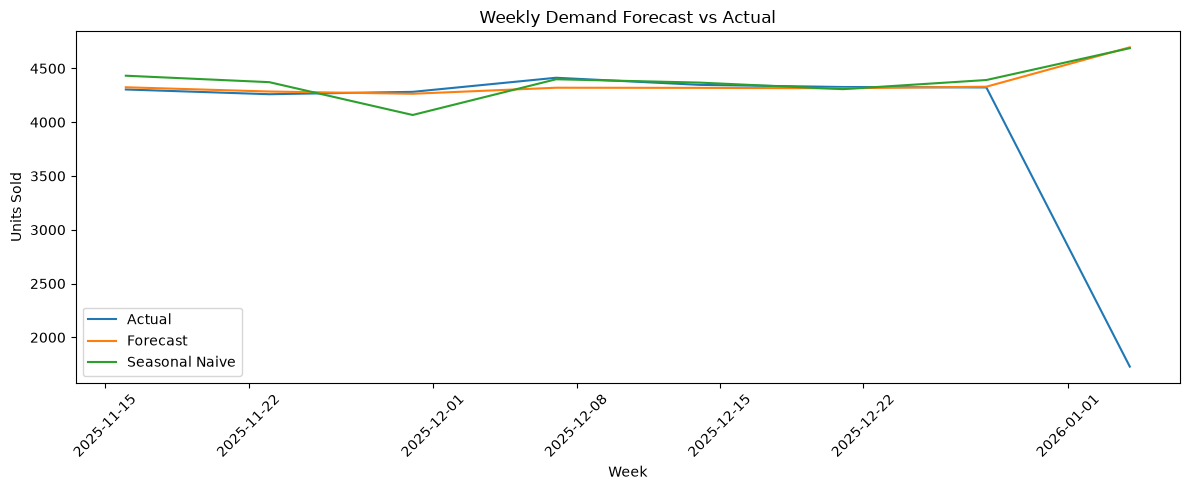

In [23]:
# Comparing actual demand with model and baseline forecasts
plot_data = (test_data.groupby("Week")[["Weekly_Demand","Forecast","Seasonal_Naive"]].sum())

plt.figure(figsize=(12, 5))

plt.plot(plot_data.index,plot_data["Weekly_Demand"],label="Actual")

plt.plot(plot_data.index,plot_data["Forecast"],label="Forecast")

plt.plot(plot_data.index,plot_data["Seasonal_Naive"],label="Seasonal Naive")

plt.title("Weekly Demand Forecast vs Actual")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Calculating forecasting accuracy separately for each SKU
sku_wape = (test_data.groupby("SKU").apply(lambda x: calculate_wape(x["Weekly_Demand"],x["Forecast"]),
                include_groups=False).reset_index(name="WAPE"))

sku_wape.head()

,SKU,WAPE
0,SKU001,15.800163
1,SKU002,24.955979
2,SKU003,24.096029
3,SKU004,26.395020
4,SKU005,13.239165


In [25]:
# Checking SKUs with the lowest forecasting error
sku_wape.sort_values("WAPE").head(10)

,SKU,WAPE
4,SKU005,13.239165
11,SKU012,13.285391
17,SKU018,13.498012
9,SKU010,13.519817
22,SKU023,14.108987
13,SKU014,14.234743
18,SKU019,14.596961
42,SKU043,14.821989
5,SKU006,14.907367
44,SKU045,15.549218


In [26]:
# Checking SKUs with the highest forecasting error
sku_wape.sort_values("WAPE",ascending=False).head(10)

,SKU,WAPE
24,SKU025,37.746438
10,SKU011,33.972387
14,SKU015,29.736672
27,SKU028,26.722513
3,SKU004,26.395020
38,SKU039,25.719637
15,SKU016,25.652219
21,SKU022,25.614333
1,SKU002,24.955979
47,SKU048,24.585716


In [27]:
# Creating the next 8 weeks for future demand forecasting
future_weeks = pd.date_range(weekly_sales["Week"].max() + pd.Timedelta(weeks=1),
                    periods=8,freq="W-SUN")

print(future_weeks)

DatetimeIndex(['2026-01-11', '2026-01-18', '2026-01-25', '2026-02-01',
               '2026-02-08', '2026-02-15', '2026-02-22', '2026-03-01'],
              dtype='datetime64[us]', freq='W-SUN')


In [28]:
# Creating future records for every SKU
future_index = pd.MultiIndex.from_product([all_skus, future_weeks],names=["SKU", "Week"])

future_data = pd.DataFrame(index=future_index).reset_index()

future_data["Weekly_Demand"] = np.nan

In [29]:
# Combining historical demand with future forecast periods
forecast_history = weekly_sales[["SKU", "Week", "Weekly_Demand"]].copy()
forecast_full = pd.concat([forecast_history,future_data],ignore_index=True)
forecast_full = forecast_full.sort_values(["SKU", "Week"]).reset_index(drop=True)

In [30]:
# Creating lag features for future forecasting
for lag in [1, 2, 4, 8, 13, 26, 52]:
    forecast_full[f"Lag_{lag}"] = (forecast_full.groupby("SKU")["Weekly_Demand"].shift(lag))


# Creating rolling demand features
forecast_full["Rolling_Mean_4"] = (forecast_full.groupby("SKU")["Weekly_Demand"].transform(lambda x: x.shift(1).rolling(4).mean()))
forecast_full["Rolling_Mean_8"] = (forecast_full.groupby("SKU")["Weekly_Demand"].transform(lambda x: x.shift(1).rolling(8).mean()))
forecast_full["Rolling_Mean_13"] = (forecast_full.groupby("SKU")["Weekly_Demand"].transform(lambda x: x.shift(1).rolling(13).mean()))


# Creating calendar features
forecast_full["Year"] = forecast_full["Week"].dt.year
forecast_full["Month"] = forecast_full["Week"].dt.month
forecast_full["Quarter"] = forecast_full["Week"].dt.quarter
forecast_full["Week_Number"] = (forecast_full["Week"].dt.isocalendar().week.astype(int))

In [31]:
# Generating future forecasts one week at a time
future_predictions = []

for week in future_weeks:
    # Selecting the current future week
    current_rows = forecast_full[forecast_full["Week"] == week].copy()

    # Generating predictions using the trained model
    current_rows["Forecast"] = model.predict(current_rows[features])

    # Making sure demand cannot be negative
    current_rows["Forecast"] = (current_rows["Forecast"].clip(lower=0))

    # Adding predictions back into the dataset
    # so later weeks can use them as lag values
    for _, row in current_rows.iterrows():
        mask = ((forecast_full["SKU"] == row["SKU"]) &(forecast_full["Week"] == week))
        forecast_full.loc[mask,"Weekly_Demand"] = row["Forecast"]

    # Saving the current week's predictions
    future_predictions.append(current_rows)

In [32]:
# Combining all future week predictions
future_forecast = pd.concat(future_predictions,ignore_index=True)

# Keeping only the important forecast columns
future_forecast = future_forecast[["SKU","Week","Forecast"]]
future_forecast.head(20)

,SKU,Week,Forecast
0,SKU001,2026-01-11,84.141026
1,SKU002,2026-01-11,60.142769
2,SKU003,2026-01-11,34.216825
3,SKU004,2026-01-11,31.710096
4,SKU005,2026-01-11,94.623975
5,SKU006,2026-01-11,38.725189
6,SKU007,2026-01-11,165.491640
7,SKU008,2026-01-11,97.849831
8,SKU009,2026-01-11,63.146935
9,SKU010,2026-01-11,106.233286


In [33]:
# Checking the final forecast size
print("Forecast rows:", len(future_forecast))
print("SKUs:", future_forecast["SKU"].nunique())
print("Weeks:", future_forecast["Week"].nunique())

Forecast rows: 400
SKUs: 50
Weeks: 8


In [34]:
# Saving the 8-week SKU forecast for later risk analysis
future_forecast.to_csv("../data/processed/sku_8_week_forecast.csv",index=False)
print("8-week forecast saved successfully")

8-week forecast saved successfully
